In [34]:
import os
import gc
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

In [35]:
def get_climate_data_optimized(filename):
    path = os.path.join(folder_path, filename)
    ds = xr.open_dataset(path)
    if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: ds = ds.mean(dim='expver')
    ds = ds.sortby('time')
    
    var_name = list(ds.data_vars)[0]
    data = ds[var_name]
    if 'temperature' in filename: data = data - 273.15
    
    ts_monthly = data.mean(dim=['latitude', 'longitude']).resample(time='1MS').mean().compute().to_dataframe(name=var_name)
    
    yearly = data.resample(time='1YS').mean()
    spatial_trend = (yearly[-5:].mean(dim='time') - yearly[:5].mean(dim='time')).compute()
    
    raw_computed = data.compute()
    ds.close()
    gc.collect()
    
    return ts_monthly, spatial_trend, raw_computed, var_name

In [36]:
df_skt, trend_skt, raw_skt, name_skt = get_climate_data_optimized('skin_temperature_merged.nc')
df_sw, trend_sw, raw_sw, name_sw = get_climate_data_optimized('volumetric_soil_water_layer_1_merged.nc')
df_lai, _, raw_lai, name_lai = get_climate_data_optimized('leaf_area_index_high_vegetation_merged.nc')

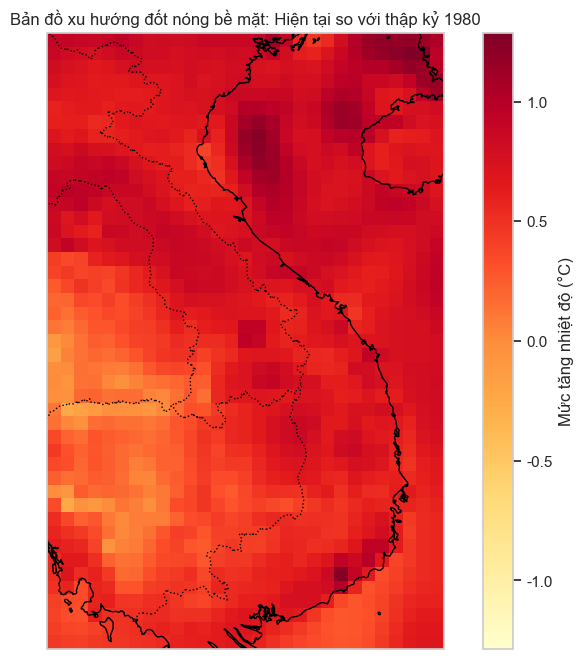

In [37]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

trend_skt.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', cbar_kwargs={'label': 'Mức tăng nhiệt độ (°C)'})
plt.title("Bản đồ xu hướng đốt nóng bề mặt: Hiện tại so với thập kỷ 1980")
plt.show()

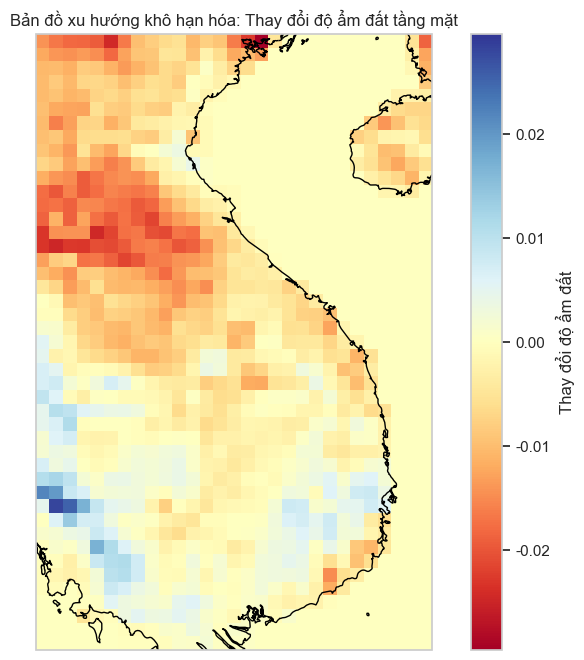

In [38]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)

trend_sw.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdYlBu', cbar_kwargs={'label': 'Thay đổi độ ẩm đất'})
plt.title("Bản đồ xu hướng khô hạn hóa: Thay đổi độ ẩm đất tầng mặt")
plt.show()

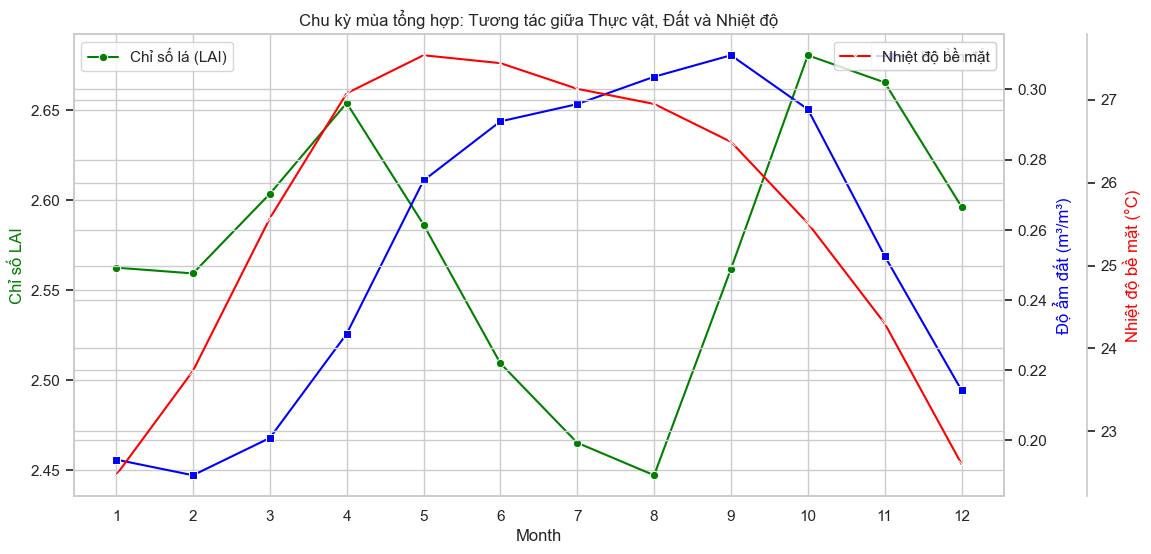

In [39]:
df_final = pd.concat([df_skt, df_sw, df_lai], axis=1).dropna()
df_final['Month'] = df_final.index.month
df_final['Decade'] = (df_final.index.year // 10) * 10

seasonal = df_final.groupby('Month').mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

sns.lineplot(data=seasonal, x=seasonal.index, y=name_lai, ax=ax1, color='green', marker='o', label='Chỉ số lá (LAI)')
sns.lineplot(data=seasonal, x=seasonal.index, y=name_sw, ax=ax2, color='blue', marker='s', label='Độ ẩm đất')
sns.lineplot(data=seasonal, x=seasonal.index, y=name_skt, ax=ax3, color='red', marker='x', label='Nhiệt độ bề mặt')

ax1.set_ylabel('Chỉ số LAI', color='green')
ax2.set_ylabel('Độ ẩm đất (m³/m³)', color='blue')
ax3.set_ylabel('Nhiệt độ bề mặt (°C)', color='red')
plt.title("Chu kỳ mùa tổng hợp: Tương tác giữa Thực vật, Đất và Nhiệt độ")
plt.xticks(range(1, 13))
plt.show()

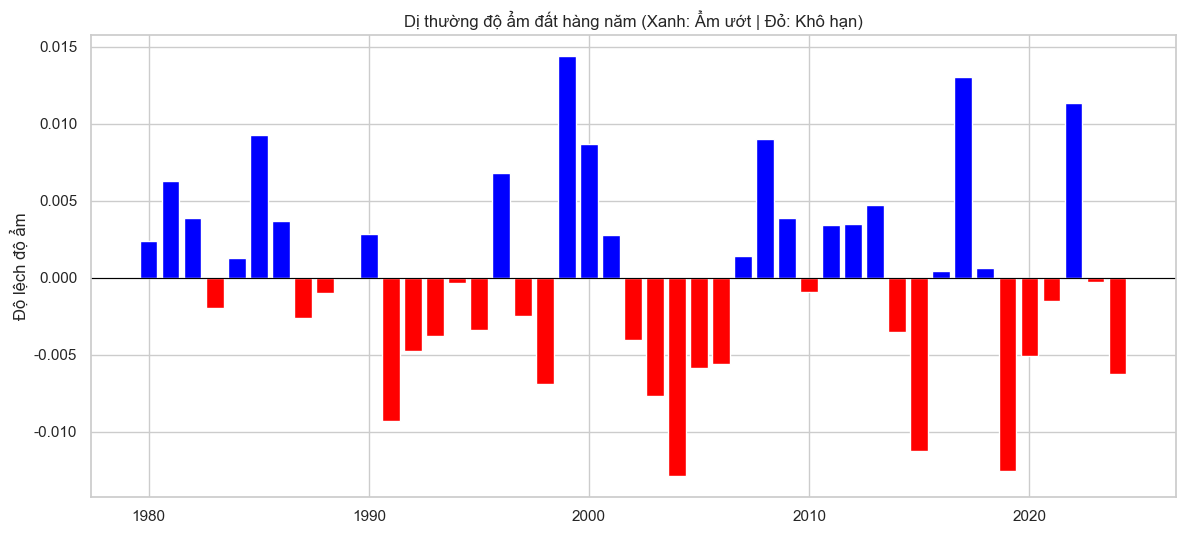

In [40]:
plt.figure(figsize=(14, 6))
df_yearly_sw = df_final[name_sw].resample('1YS').mean()
sw_anom = df_yearly_sw - df_yearly_sw.mean()

colors = ['blue' if x > 0 else 'red' for x in sw_anom]
plt.bar(df_yearly_sw.index.year, sw_anom, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Dị thường độ ẩm đất hàng năm (Xanh: Ẩm ướt | Đỏ: Khô hạn)")
plt.ylabel("Độ lệch độ ẩm")
plt.show()

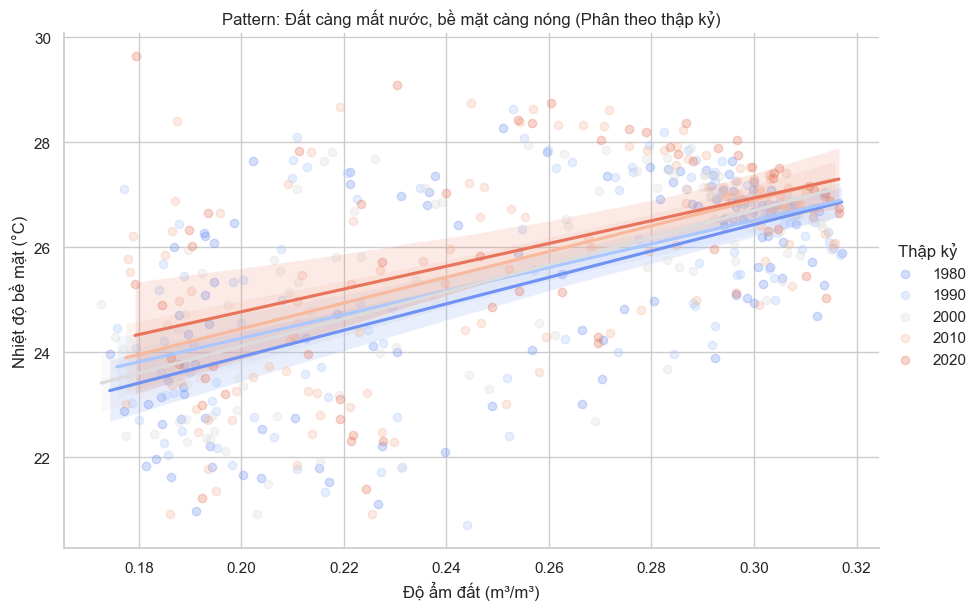

In [41]:
chart = sns.lmplot(data=df_final, x=name_sw, y=name_skt, hue='Decade', 
                   palette='coolwarm', scatter_kws={'alpha':0.3}, height=6, aspect=1.5)
plt.title("Pattern: Đất càng mất nước, bề mặt càng nóng (Phân theo thập kỷ)")
plt.xlabel("Độ ẩm đất (m³/m³)")
plt.ylabel("Nhiệt độ bề mặt (°C)")
chart._legend.set_title("Thập kỷ")
plt.show()

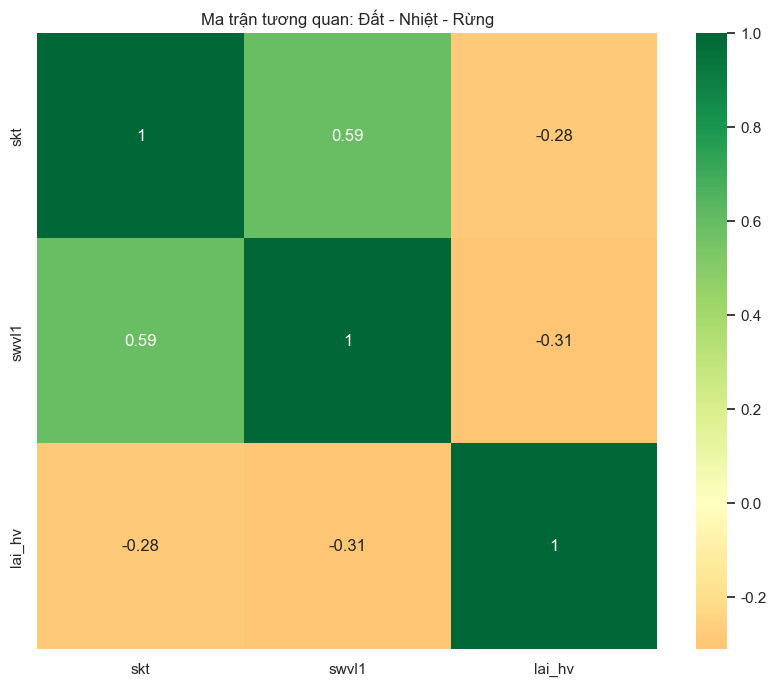

In [42]:
plt.figure(figsize=(10, 8))
corr_matrix = df_final[[name_skt, name_sw, name_lai]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title("Ma trận tương quan: Đất - Nhiệt - Rừng")
plt.show()

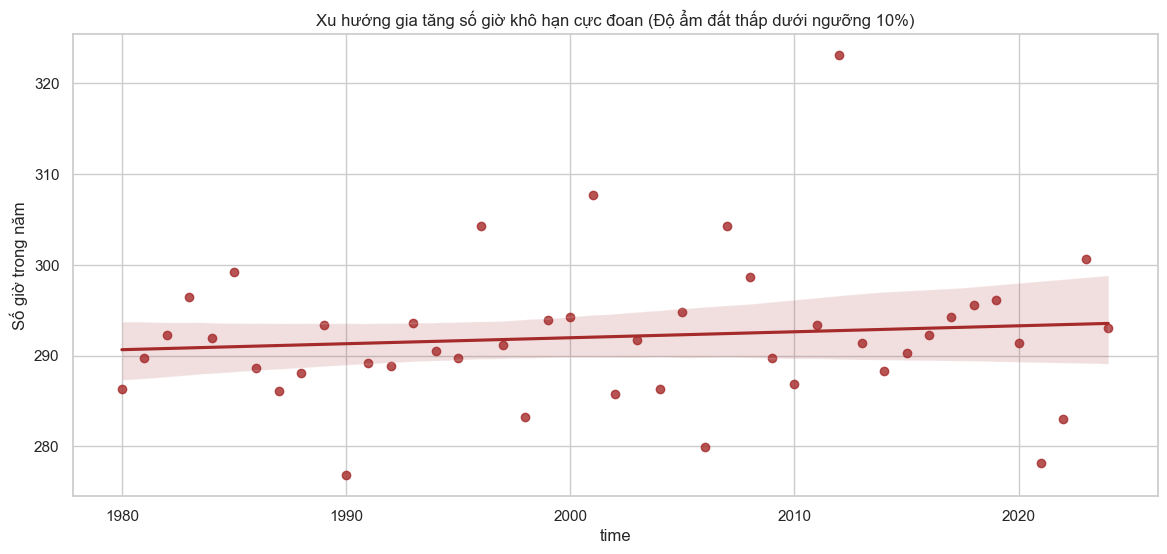

In [43]:
low_sw_threshold = raw_sw.quantile(0.1)
drought_ts = (raw_sw < low_sw_threshold).resample(time='1YS').sum(dim='time').mean(dim=['latitude', 'longitude']).to_dataframe(name='drought_hours')

plt.figure(figsize=(14, 6))
sns.regplot(x=drought_ts.index.year, y=drought_ts['drought_hours'], color='brown')
plt.title("Xu hướng gia tăng số giờ khô hạn cực đoan (Độ ẩm đất thấp dưới ngưỡng 10%)")
plt.ylabel("Số giờ trong năm")
plt.show()

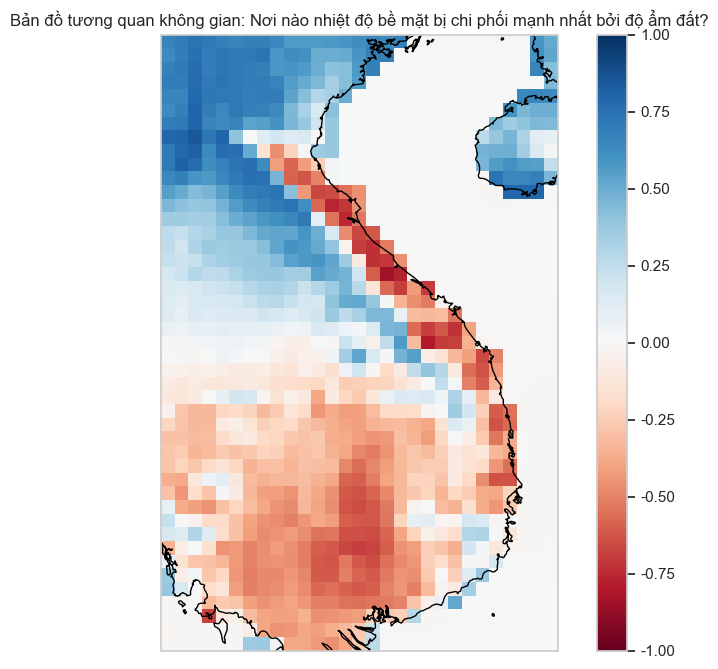

In [44]:
fig = plt.figure(figsize=(10, 8))
skt_m = raw_skt.resample(time='1MS').mean()
sw_m = raw_sw.resample(time='1MS').mean()
spatial_corr = xr.corr(skt_m, sw_m, dim='time').compute()

ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
spatial_corr.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu', vmin=-1, vmax=1)
plt.title("Bản đồ tương quan không gian: Nơi nào nhiệt độ bề mặt bị chi phối mạnh nhất bởi độ ẩm đất?")
plt.show()

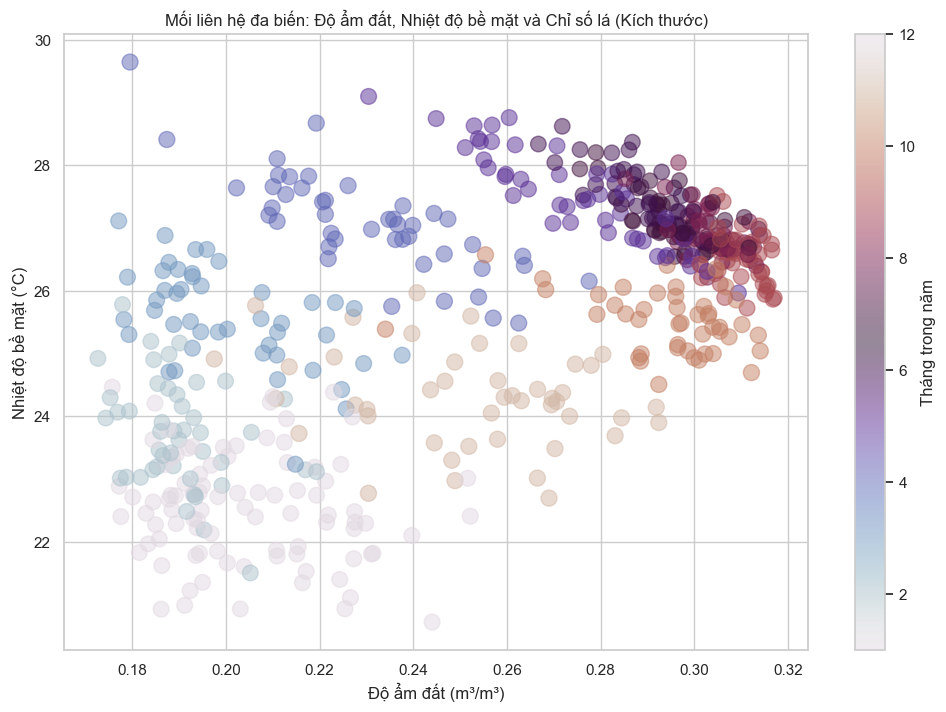

In [45]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_final[name_sw], df_final[name_skt], 
                      s=df_final[name_lai]*50, 
                      c=df_final['Month'], 
                      cmap='twilight', alpha=0.5)

plt.colorbar(scatter, label='Tháng trong năm')
plt.title("Mối liên hệ đa biến: Độ ẩm đất, Nhiệt độ bề mặt và Chỉ số lá (Kích thước)")
plt.xlabel("Độ ẩm đất (m³/m³)")
plt.ylabel("Nhiệt độ bề mặt (°C)")
plt.show()

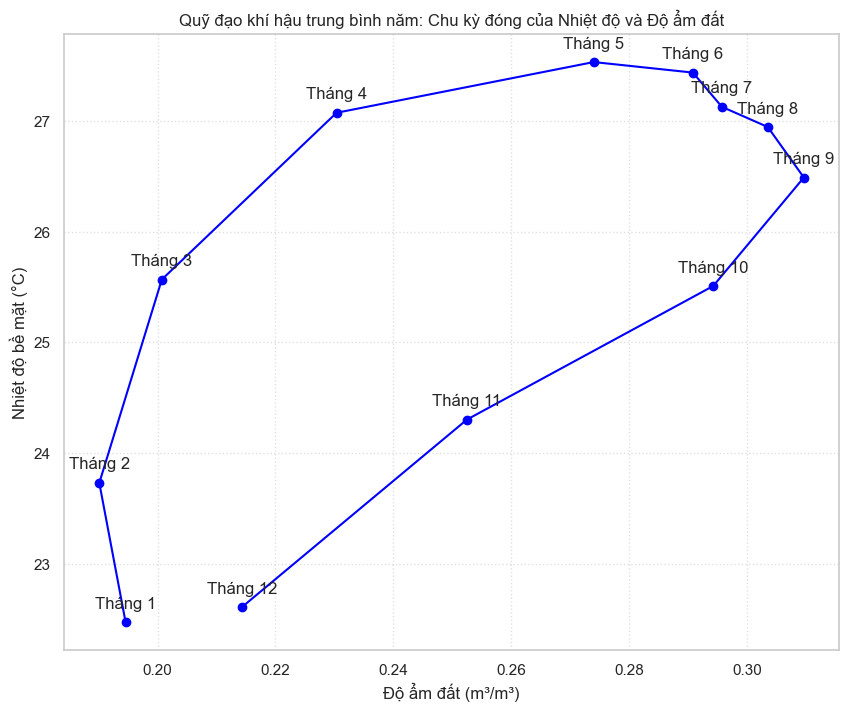

In [46]:
plt.figure(figsize=(10, 8))
plt.plot(seasonal[name_sw], seasonal[name_skt], marker='o', linestyle='-', color='blue')

for i, txt in enumerate(range(1, 13)):
    plt.annotate(f"Tháng {txt}", (seasonal[name_sw].iloc[i], seasonal[name_skt].iloc[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Quỹ đạo khí hậu trung bình năm: Chu kỳ đóng của Nhiệt độ và Độ ẩm đất")
plt.xlabel("Độ ẩm đất (m³/m³)")
plt.ylabel("Nhiệt độ bề mặt (°C)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()